# 02 · Sleep staging results

Cross-validated results of Phase 2. Every number comes from a config-driven run in `results/`
(the latest complete run of each experiment; partial runs are ignored), using the fixed 5-fold
subject split in `configs/splits/subject_folds.json`. Nothing here is fitted or tuned; the
notebook only reads predictions and metrics.

- **Population models:** gradient-boosted trees (`hgb_main`) and a bidirectional GRU over whole
  nights (`gru_main`), scored on every labelled epoch of every test subject.
- **Personalization (N = 1–3 prior nights):** scored on the fixed evaluation nights (night 4+ of
  the 43 subjects with at least 4 nights). `prior_norm` needs no labels; `prior_stage` uses the
  prior nights' expert labels and is an upper bound. `matched` is the control: same training
  nights, no personal features.
- **Sensitivity analyses:** expert labels shifted by the lag estimated on training subjects, and
  training on the automatic Dreem labels.

Scores: Cohen's kappa, macro-F1 (over stages present), accuracy and ECE; pooled over epochs with
95% CIs from resampling subjects, plus per-subject mean ± SD.

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import cohen_kappa_score

from sleepwatch.config import get_settings
from sleepwatch.models.metrics import (
    CLASS_NAMES,
    calibration_bins,
    confusion,
    labels_and_proba,
    paired_difference,
    per_group_scores,
    summarize,
)

RESULTS = get_settings().results_dir
index = pd.read_csv(RESULTS / "index.csv")
latest = index[~index["partial"]].groupby("name").tail(1).set_index("name")


def load(name):
    run_dir = RESULTS / name / latest.loc[name, "run"]
    return {
        "metrics": json.loads((run_dir / "metrics.json").read_text()),
        "pred": pd.read_parquet(run_dir / "predictions.parquet"),
        "run": json.loads((run_dir / "run.json").read_text()),
    }


runs = {name: load(name) for name in latest.index}
display(
    latest[["run", "model", "commit", "dirty", "kappa_5", "macro_f1_5", "kappa_4", "macro_f1_4"]]
)
assert not latest["dirty"].any(), "a run was made from uncommitted code"

COLORS = {
    "hgb": "#2a78d6",
    "gru": "#eb6834",
    "matched": "#a9a8a3",
    "prior_norm": "#2a78d6",
    "prior_stage": "#eb6834",
}
SEQ = ["#fcfcfb", "#cde2fb", "#6da7ec", "#256abf", "#0d366b"]
plt.rcParams.update(
    {
        "figure.facecolor": "#fcfcfb",
        "axes.facecolor": "#fcfcfb",
        "axes.edgecolor": "#a9a8a3",
        "axes.labelcolor": "#52514e",
        "xtick.color": "#52514e",
        "ytick.color": "#52514e",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": "#e6e5e1",
        "grid.linewidth": 0.6,
        "lines.linewidth": 1.5,
        "axes.titlesize": 11,
        "axes.titleweight": "bold",
        "font.size": 9,
        "legend.frameon": False,
    }
)


def fmt(summary, metric):
    low, high = summary["ci95"][metric]
    return f"{summary['pooled'][metric]:.3f} [{low:.3f}, {high:.3f}]"

,run,model,commit,dirty,kappa_5,macro_f1_5,kappa_4,macro_f1_4
name,,,,,,,,
gru_personal,20261001T231831Z,gru,69468d94,False,0.5100,0.5665,0.5329,0.6765
gru_main,20261002T083326Z,gru,69468d94,False,0.5100,0.5665,0.5329,0.6765
gru_shifted,20261002T083526Z,gru,69468d94,False,0.5091,0.5653,0.5337,0.6753
hgb_expanding,20261002T084238Z,hgb,69468d94,False,0.3815,0.5039,0.3902,0.5838
hgb_main,20261002T090148Z,hgb,69468d94,False,0.3815,0.5039,0.3902,0.5838
hgb_shifted,20261002T090701Z,hgb,69468d94,False,0.3844,0.5098,0.4023,0.5925
hgb_dreem_labels,20261002T091349Z,hgb,69468d94,False,0.3787,0.4880,0.3936,0.5811


## 1 · Population models

All labelled epochs of all 47 test subjects (each subject is a test subject in exactly one
fold). "Covered" restricts to epochs where both heart rate and motion cover at least half the
epoch. The model difference at the end is paired: each bootstrap draw resamples subjects once
and scores both models on the same epochs.

In [2]:
rows = []
for name in ["hgb_main", "gru_main"]:
    for subset in ["all", "covered"]:
        for scheme in ["5", "4"]:
            s = runs[name]["metrics"]["population"][subset][scheme]
            per_subject = f"{s['subject_mean']['kappa']:.3f} ± {s['subject_sd']['kappa']:.3f}"
            rows.append(
                {
                    "model": name,
                    "epochs": subset,
                    "classes": scheme,
                    "kappa [95% CI]": fmt(s, "kappa"),
                    "macro-F1 [95% CI]": fmt(s, "macro_f1"),
                    "accuracy": round(s["pooled"]["accuracy"], 3),
                    "ECE": round(s["pooled"]["ece"], 3),
                    "kappa per subject (mean ± SD)": per_subject,
                    "n epochs": s["pooled"]["epochs"],
                }
            )
display(pd.DataFrame(rows))

stage_rows = []
for name in ["hgb_main", "gru_main"]:
    for scheme in ["5", "4"]:
        pooled = runs[name]["metrics"]["population"]["all"][scheme]["pooled"]
        stage_rows.append(
            {
                "model": name,
                "classes": scheme,
                **{k[3:]: round(v, 3) for k, v in pooled.items() if k.startswith("f1_")},
            }
        )
print("F1 per stage")
display(pd.DataFrame(stage_rows))

population = {
    n: runs[n]["pred"][runs[n]["pred"]["method"] == "population"] for n in ["hgb_main", "gru_main"]
}
for scheme in ["5", "4"]:
    d = paired_difference(population["hgb_main"], population["gru_main"], scheme, n_boot=1000)
    print(
        f"GRU minus boosting, {scheme}-class: "
        + "; ".join(
            f"{m} {d[m]['diff']:+.3f} [{d[m]['ci95'][0]:+.3f}, {d[m]['ci95'][1]:+.3f}]"
            for m in ["kappa", "macro_f1", "accuracy"]
        )
    )

,model,epochs,classes,kappa [95% CI],macro-F1 [95% CI],accuracy,ECE,kappa per subject (mean ± SD),n epochs
0,hgb_main,all,5,"0.381 [0.357, 0.404]","0.504 [0.487, 0.519]",0.522,0.048,0.377 ± 0.080,215914
1,hgb_main,all,4,"0.390 [0.366, 0.413]","0.584 [0.565, 0.602]",0.592,0.041,0.383 ± 0.082,215914
2,hgb_main,covered,5,"0.391 [0.364, 0.414]","0.510 [0.492, 0.526]",0.531,0.042,0.386 ± 0.083,203198
3,hgb_main,covered,4,"0.396 [0.371, 0.419]","0.589 [0.570, 0.608]",0.594,0.038,0.389 ± 0.085,203198
4,gru_main,all,5,"0.510 [0.482, 0.537]","0.566 [0.549, 0.583]",0.644,0.037,0.506 ± 0.096,215914
5,gru_main,all,4,"0.533 [0.503, 0.560]","0.677 [0.656, 0.696]",0.684,0.042,0.527 ± 0.100,215914
6,gru_main,covered,5,"0.519 [0.491, 0.546]","0.573 [0.556, 0.590]",0.650,0.034,0.514 ± 0.096,203198
7,gru_main,covered,4,"0.539 [0.509, 0.567]","0.682 [0.661, 0.701]",0.687,0.040,0.533 ± 0.101,203198


F1 per stage


,model,classes,Wake,N1,N2,N3,REM,Light,Deep
0,hgb_main,5,0.601,0.236,0.526,0.615,0.542,NaN,NaN
1,hgb_main,4,0.610,NaN,NaN,NaN,0.480,0.630,0.615
2,gru_main,5,0.655,0.155,0.660,0.686,0.676,NaN,NaN
3,gru_main,4,0.655,NaN,NaN,NaN,0.667,0.699,0.685


GRU minus boosting, 5-class: kappa +0.129 [+0.113, +0.145]; macro_f1 +0.063 [+0.052, +0.074]; accuracy +0.122 [+0.109, +0.135]
GRU minus boosting, 4-class: kappa +0.143 [+0.125, +0.161]; macro_f1 +0.093 [+0.081, +0.105]; accuracy +0.092 [+0.080, +0.104]


## 2 · Confusion matrices (population models, all epochs; row = expert stage)

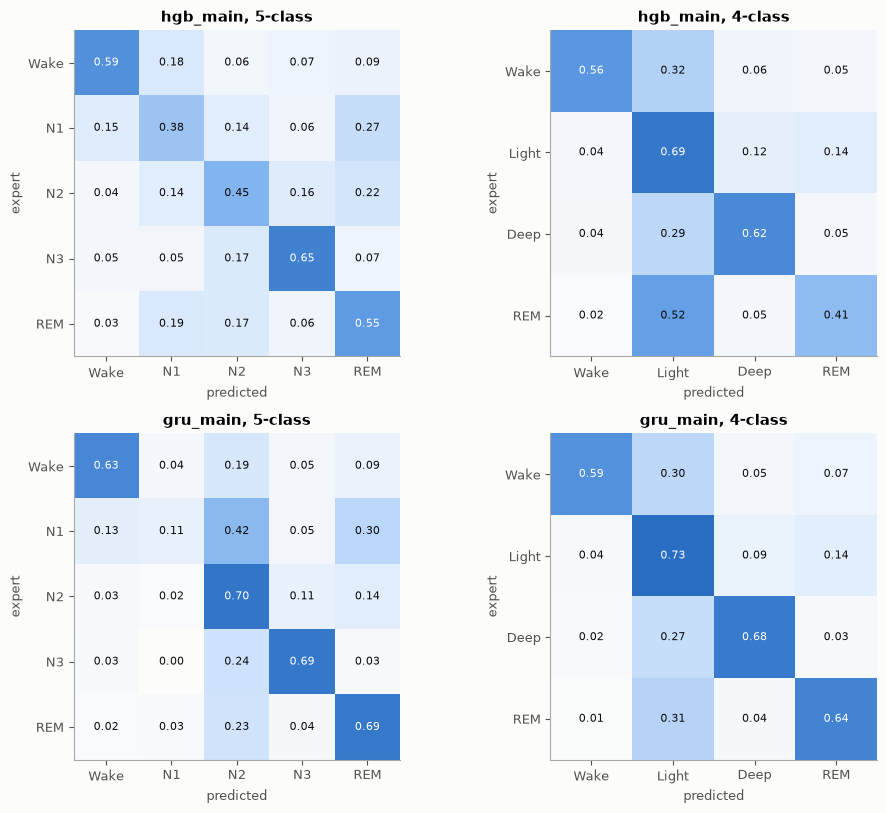

In [3]:
from matplotlib.colors import LinearSegmentedColormap

cmap = LinearSegmentedColormap.from_list("blue", SEQ)
fig, axes = plt.subplots(2, 2, figsize=(10, 8.2))
for row, name in enumerate(["hgb_main", "gru_main"]):
    pred = runs[name]["pred"]
    pred = pred[pred["method"] == "population"]
    for col, scheme in enumerate(["5", "4"]):
        y, proba = labels_and_proba(pred, scheme)
        names = CLASS_NAMES[scheme]
        cm = confusion(y, proba.argmax(axis=1), len(names))
        share = cm / cm.sum(axis=1, keepdims=True)
        ax = axes[row, col]
        ax.imshow(share, cmap=cmap, vmin=0, vmax=1)
        ax.set_xticks(range(len(names)), names)
        ax.set_yticks(range(len(names)), names)
        ax.grid(False)
        ax.set(title=f"{name}, {scheme}-class", xlabel="predicted", ylabel="expert")
        for i in range(len(names)):
            for j in range(len(names)):
                ax.text(
                    j,
                    i,
                    f"{share[i, j]:.2f}",
                    ha="center",
                    va="center",
                    fontsize=8,
                    color="#ffffff" if share[i, j] > 0.55 else "#0b0b0b",
                )
plt.tight_layout()
plt.show()

## 3 · Calibration

Reliability of the top predicted stage (5-class): mean confidence vs observed accuracy per
confidence bin. Points on the diagonal are perfectly calibrated. No recalibration was applied.

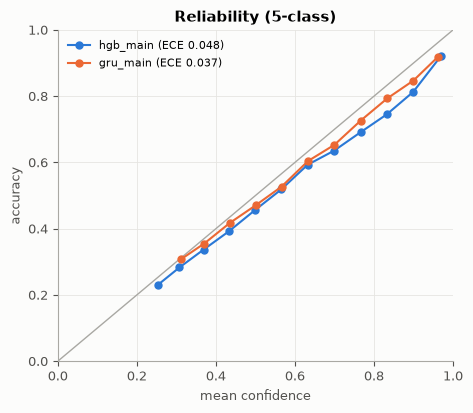

In [4]:
fig, ax = plt.subplots(figsize=(4.8, 4.2))
ax.plot([0, 1], [0, 1], color="#a9a8a3", lw=1)
for name, model in [("hgb_main", "hgb"), ("gru_main", "gru")]:
    pred = runs[name]["pred"]
    y, proba = labels_and_proba(pred[pred["method"] == "population"], "5")
    bins = calibration_bins(y, proba)
    used = bins[:, 0] > 200
    ece = runs[name]["metrics"]["population"]["all"]["5"]["pooled"]["ece"]
    ax.plot(
        bins[used, 1] / bins[used, 0],
        bins[used, 2] / bins[used, 0],
        marker="o",
        ms=5,
        color=COLORS[model],
        label=f"{name} (ECE {ece:.3f})",
    )
ax.set(
    title="Reliability (5-class)",
    xlabel="mean confidence",
    ylabel="accuracy",
    xlim=(0, 1),
    ylim=(0, 1),
)
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

## 4 · Spread across people and nights

Pooled scores hide how much staging quality varies. Per-night kappa (5-class) for the better
population model, with the nights flagged in Phase 1 called out: `Bidslab01/4` (Dreem and
expert labels disagree), `Bidslab47/2` (low Dreem–expert agreement) and `Bidslab06/2`
(interleaved HR streams). The table at the end lists the five worst nights.

gru_main: per-night kappa median 0.521, IQR 0.433-0.611; per-subject range 0.247-0.662


,,kappa,macro_f1,accuracy,epochs
subject,night,,,,
Bidslab01,4,0.499,0.535,0.622,760
Bidslab47,2,0.269,0.425,0.462,937
Bidslab06,2,0.226,0.278,0.461,852


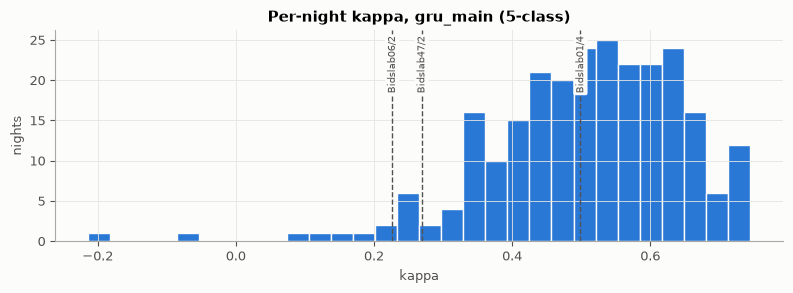

,,kappa,macro_f1,accuracy,epochs
subject,night,,,,
Bidslab42,1,-0.213,0.113,0.131,815
Bidslab68,2,-0.055,0.161,0.298,796
Bidslab47,1,0.081,0.257,0.264,931
Bidslab34,1,0.129,0.312,0.438,1336
Bidslab15,1,0.156,0.386,0.347,750


In [5]:
best = max(
    ["hgb_main", "gru_main"],
    key=lambda n: runs[n]["metrics"]["population"]["all"]["5"]["pooled"]["kappa"],
)
pred = runs[best]["pred"]
pred = pred[pred["method"] == "population"]
per_night = per_group_scores(pred, ["subject", "night"])
per_subject = per_group_scores(pred, ["subject"])
print(
    f"{best}: per-night kappa median {per_night['kappa'].median():.3f}, "
    f"IQR {per_night['kappa'].quantile(0.25):.3f}-{per_night['kappa'].quantile(0.75):.3f}; "
    f"per-subject range {per_subject['kappa'].min():.3f}-{per_subject['kappa'].max():.3f}"
)
flagged = [("Bidslab01", 4), ("Bidslab47", 2), ("Bidslab06", 2)]
display(per_night.loc[flagged, ["kappa", "macro_f1", "accuracy", "epochs"]].round(3))

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(per_night["kappa"], bins=30, color="#2a78d6", edgecolor="#fcfcfb")
for subject, night in flagged:
    k = per_night.loc[(subject, night), "kappa"]
    ax.axvline(k, color="#52514e", lw=1, ls="--")
    ax.annotate(
        f"{subject}/{night}",
        (k, ax.get_ylim()[1] * 0.97),
        rotation=90,
        fontsize=7,
        ha="center",
        va="top",
        color="#52514e",
        bbox={"boxstyle": "round,pad=0.2", "fc": "#fcfcfb", "ec": "none"},
    )
ax.set(title=f"Per-night kappa, {best} (5-class)", xlabel="kappa", ylabel="nights")
plt.tight_layout()
plt.show()
display(per_night.nsmallest(5, "kappa")[["kappa", "macro_f1", "accuracy", "epochs"]].round(3))

## 5 · Two nights whose labels don't line up with the watch

The two worst nights above are timing problems, not hard nights. For every night, the
cross-validated GRU predictions (the night's subject was a test subject, so nothing here is
fitted on it) are paired with the expert labels at every lag up to ±150 epochs (±75 min): label
epoch `k` against the prediction for epoch `k + lag`. On `Bidslab42/1` and `Bidslab68/2`,
agreement peaks far from 0, at a lag that equals the delay between `recStart` and the first
watch sample. The labels appear to start when the watch starts, not at `recStart`. On every other
night the curve is flat around lag 0.

A late watch start doesn't predict this on its own (`Bidslab14/4` starts 122 min late and is
aligned at lag 0), so it couldn't have been caught without labels. **Nothing is corrected or
dropped:** the headline numbers above include both nights. The last table shows what excluding
them would change. It is a sensitivity check chosen after looking at test predictions, not a
result.

,,kappa at lag 0,best lag,kappa at best lag,gain,watch start - recStart (epochs)
subject,night,,,,,
Bidslab42,1,-0.21,62,0.57,0.78,61.43
Bidslab68,2,-0.05,118,0.32,0.38,118.39


other 251 nights: largest gain 0.060; best lag within ±3 epochs on 203
other nights where the watch starts > 20 min late:


kappa at lag 0  best lag  kappa at best lag  gain  \
subject   night                                                      
Bidslab02 2                0.52         5               0.53  0.01   
          4                0.56        -1               0.56  0.00   
Bidslab14 4                0.48         0               0.48  0.00   

                 watch start - recStart (epochs)  
subject   night                                   
Bidslab02 2                                41.19  
          4                                95.15  
Bidslab14 4                               244.28

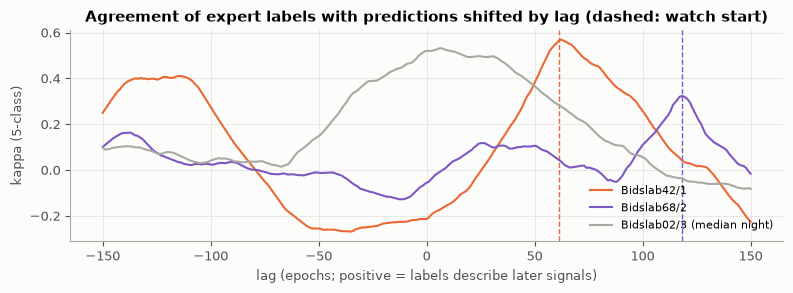

,model,classes,nights,kappa [95% CI],macro-F1 [95% CI],accuracy
0,hgb_main,5,all nights,"0.381 [0.357, 0.404]","0.504 [0.487, 0.519]",0.522
1,hgb_main,5,without the two,"0.384 [0.359, 0.407]","0.506 [0.489, 0.521]",0.524
2,hgb_main,4,all nights,"0.390 [0.366, 0.413]","0.584 [0.565, 0.602]",0.592
3,hgb_main,4,without the two,"0.393 [0.369, 0.416]","0.586 [0.568, 0.604]",0.594
4,gru_main,5,all nights,"0.510 [0.482, 0.537]","0.566 [0.549, 0.583]",0.644
5,gru_main,5,without the two,"0.515 [0.487, 0.541]","0.569 [0.552, 0.585]",0.647
6,gru_main,4,all nights,"0.533 [0.503, 0.560]","0.677 [0.656, 0.696]",0.684
7,gru_main,4,without the two,"0.538 [0.510, 0.565]","0.680 [0.660, 0.700]",0.688


In [6]:
from sleepwatch.features.build import load_build

_, quality, _ = load_build("v1", get_settings().processed_dir)
quality = quality.set_index(["subject", "night"])
pred = runs["gru_main"]["pred"]
pred = pred[pred["method"] == "population"]
LAGS = np.arange(-150, 151)


def kappa_by_lag(night):
    length = int(night["epoch"].max()) + 1
    truth, guess = np.full(length, -1), np.full(length, -1)
    truth[night["epoch"]] = night["y_true"]
    guess[night["epoch"]] = night[[f"proba_{i}" for i in range(5)]].to_numpy().argmax(axis=1)
    out = []
    for lag in LAGS:
        a = truth[max(0, -lag) : length - max(0, lag)]
        b = guess[max(0, lag) : length - max(0, -lag)]  # label k vs prediction k + lag
        keep = (a >= 0) & (b >= 0)
        ok = keep.sum() > 200 and len(set(a[keep])) > 1
        out.append(cohen_kappa_score(a[keep], b[keep]) if ok else np.nan)
    return np.array(out)


curves = {key: kappa_by_lag(night) for key, night in pred.groupby(["subject", "night"])}
scan = pd.DataFrame(
    [
        {
            "subject": s,
            "night": n,
            "kappa at lag 0": c[LAGS == 0][0],
            "best lag": int(LAGS[np.nanargmax(c)]),
            "kappa at best lag": np.nanmax(c),
        }
        for (s, n), c in curves.items()
    ]
).set_index(["subject", "night"])
scan["gain"] = scan["kappa at best lag"] - scan["kappa at lag 0"]
scan["watch start - recStart (epochs)"] = quality["hr_start_offset_min"] * 2
misaligned = scan[scan["gain"] > 0.1]
display(misaligned.round(2))
others = scan.drop(misaligned.index)
print(
    f"other {len(others)} nights: largest gain {others['gain'].max():.3f}; "
    f"best lag within ±3 epochs on {(others['best lag'].abs() <= 3).sum()}"
)
late = scan[(scan["watch start - recStart (epochs)"] > 40)].drop(misaligned.index)
print("other nights where the watch starts > 20 min late:")
display(late.round(2))

fig, ax = plt.subplots(figsize=(8, 3))
typical = scan["kappa at lag 0"].sub(scan["kappa at lag 0"].median()).abs().idxmin()
for key, color in zip([*misaligned.index, typical], ["#eb6834", "#7e57c2", "#a9a8a3"], strict=True):
    label = f"{key[0]}/{key[1]}" + (" (median night)" if key == typical else "")
    ax.plot(LAGS, curves[key], color=color, label=label)
    if key != typical:
        ax.axvline(scan.loc[key, "watch start - recStart (epochs)"], color=color, lw=1, ls="--")
ax.set(
    title="Agreement of expert labels with predictions shifted by lag (dashed: watch start)",
    xlabel="lag (epochs; positive = labels describe later signals)",
    ylabel="kappa (5-class)",
)
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

rows = []
for name in ["hgb_main", "gru_main"]:
    p = runs[name]["pred"]
    p = p[p["method"] == "population"]
    keep = ~p.set_index(["subject", "night"]).index.isin(misaligned.index)
    for scheme in ["5", "4"]:
        for subset, frame in [("all nights", p), ("without the two", p[keep])]:
            s = summarize(frame, scheme, n_boot=1000, seed=42)
            rows.append(
                {
                    "model": name,
                    "classes": scheme,
                    "nights": subset,
                    "kappa [95% CI]": fmt(s, "kappa"),
                    "macro-F1 [95% CI]": fmt(s, "macro_f1"),
                    "accuracy": round(s["pooled"]["accuracy"], 3),
                }
            )
display(pd.DataFrame(rows))

## 6 · Personalization: does knowing a person's earlier nights help?

Scored on the same fixed evaluation nights for every N. The comparison that answers the
question is **personalized vs `matched`** at the same N: both are trained on exactly the same
nights, so the only difference is the personal features. (Personalized vs the population model
at N = 0 mixes in the effect of the smaller training set.) Differences are paired: each
bootstrap draw resamples subjects once and scores both models.

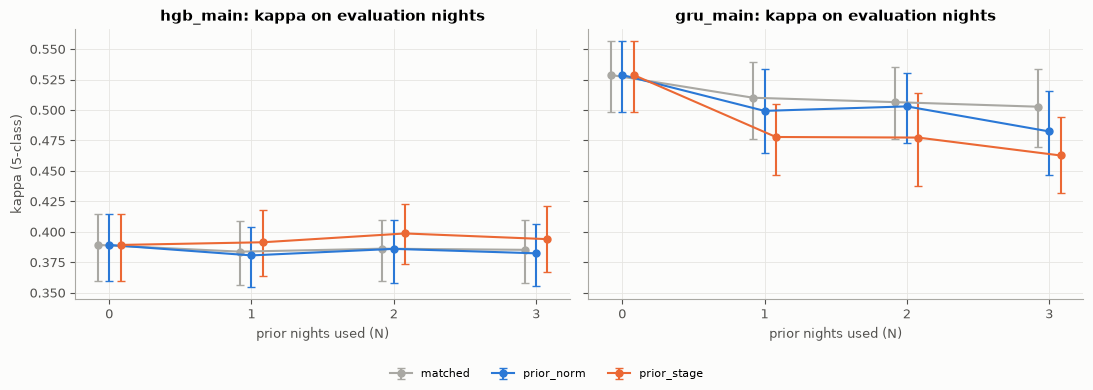

,model,method,N,compared with,kappa difference,95% CI
0,hgb_main,prior_norm,1,matched,-0.003,"[-0.012, 0.005]"
1,hgb_main,prior_norm,2,matched,-0.000,"[-0.010, 0.010]"
2,hgb_main,prior_norm,3,matched,-0.003,"[-0.012, 0.006]"
3,hgb_main,prior_stage,1,matched,0.008,"[-0.002, 0.018]"
4,hgb_main,prior_stage,2,matched,0.012,"[0.004, 0.022]"
5,hgb_main,prior_stage,3,matched,0.009,"[-0.000, 0.017]"
6,gru_main,prior_norm,1,matched,-0.011,"[-0.040, 0.015]"
7,gru_main,prior_norm,2,matched,-0.003,"[-0.018, 0.012]"
8,gru_main,prior_norm,3,matched,-0.020,"[-0.045, 0.001]"
9,gru_main,prior_stage,1,matched,-0.032,"[-0.056, -0.009]"


,model,method,N,compared with,kappa difference,95% CI
0,hgb_main,prior_norm,1,population,-0.009,"[-0.017, 0.001]"
1,hgb_main,prior_norm,2,population,-0.003,"[-0.014, 0.009]"
2,hgb_main,prior_norm,3,population,-0.007,"[-0.018, 0.005]"
3,hgb_main,prior_stage,1,population,0.002,"[-0.008, 0.012]"
4,hgb_main,prior_stage,2,population,0.009,"[-0.001, 0.020]"
5,hgb_main,prior_stage,3,population,0.005,"[-0.007, 0.017]"
6,gru_main,prior_norm,1,population,-0.029,"[-0.060, -0.004]"
7,gru_main,prior_norm,2,population,-0.026,"[-0.042, -0.010]"
8,gru_main,prior_norm,3,population,-0.046,"[-0.073, -0.022]"
9,gru_main,prior_stage,1,population,-0.051,"[-0.071, -0.031]"


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.9), sharey=True)
diff_rows = []
for ax, name in zip(axes, ["hgb_main", "gru_main"], strict=True):
    curve = runs[name]["metrics"]["n_curve"]
    for offset, method in zip(
        [-0.08, 0.0, 0.08], ["matched", "prior_norm", "prior_stage"], strict=True
    ):
        ns = sorted(int(n) for n in curve[method])
        k = [curve[method][str(n)]["5"]["pooled"]["kappa"] for n in ns]
        ci = np.array([curve[method][str(n)]["5"]["ci95"]["kappa"] for n in ns])
        ax.errorbar(
            np.array(ns) + offset,
            k,
            yerr=[np.array(k) - ci[:, 0], ci[:, 1] - np.array(k)],
            color=COLORS[method],
            marker="o",
            ms=5,
            capsize=3,
            label=method,
        )
        for n in ns:
            entry = curve[method][str(n)]
            for ref in ["vs_matched", "vs_population"]:
                if ref in entry:
                    d = entry[ref]["5"]["kappa"]
                    diff_rows.append(
                        {
                            "model": name,
                            "method": method,
                            "N": n,
                            "compared with": ref[3:],
                            "kappa difference": round(d["diff"], 3),
                            "95% CI": f"[{d['ci95'][0]:.3f}, {d['ci95'][1]:.3f}]",
                        }
                    )
    ax.set(
        title=f"{name}: kappa on evaluation nights",
        xlabel="prior nights used (N)",
        xticks=[0, 1, 2, 3],
    )
axes[0].set_ylabel("kappa (5-class)")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, fontsize=8)
plt.tight_layout(rect=(0, 0.08, 1, 1))
plt.show()
diffs = pd.DataFrame(diff_rows)
display(diffs[diffs["compared with"] == "matched"].reset_index(drop=True))
display(
    diffs[(diffs["compared with"] == "population") & (diffs["method"] != "matched")].reset_index(
        drop=True
    )
)

## 7 · Label-timing sensitivity

Phase 1 found the expert labels running about 3 epochs late relative to the watch signals.
The headline results above use the documented alignment. Here the same population models are
retrained and rescored with the expert labels re-paired by the lag estimated on each fold's
training subjects. The shifted runs are scored against the shifted labels, so this shows how
much the alignment choice moves the numbers, not which alignment is right.

In [8]:
rows = []
for model in ["hgb", "gru"]:
    for name, alignment in [(f"{model}_main", "documented"), (f"{model}_shifted", "shifted")]:
        if name not in runs:
            continue
        for scheme in ["5", "4"]:
            s = runs[name]["metrics"]["population"]["all"][scheme]
            rows.append(
                {
                    "model": model,
                    "alignment": alignment,
                    "classes": scheme,
                    "kappa [95% CI]": fmt(s, "kappa"),
                    "macro-F1 [95% CI]": fmt(s, "macro_f1"),
                    "accuracy": round(s["pooled"]["accuracy"], 3),
                }
            )
display(pd.DataFrame(rows))
for name in ["hgb_shifted", "gru_shifted"]:
    if name in runs:
        print(name, "estimated lag per fold:", [f["label_lag"] for f in runs[name]["run"]["folds"]])

,model,alignment,classes,kappa [95% CI],macro-F1 [95% CI],accuracy
0,hgb,documented,5,"0.381 [0.357, 0.404]","0.504 [0.487, 0.519]",0.522
1,hgb,documented,4,"0.390 [0.366, 0.413]","0.584 [0.565, 0.602]",0.592
2,hgb,shifted,5,"0.384 [0.360, 0.406]","0.510 [0.492, 0.525]",0.523
3,hgb,shifted,4,"0.402 [0.377, 0.425]","0.592 [0.574, 0.611]",0.600
4,gru,documented,5,"0.510 [0.482, 0.537]","0.566 [0.549, 0.583]",0.644
5,gru,documented,4,"0.533 [0.503, 0.560]","0.677 [0.656, 0.696]",0.684
6,gru,shifted,5,"0.509 [0.480, 0.535]","0.565 [0.549, 0.581]",0.645
7,gru,shifted,4,"0.534 [0.503, 0.559]","0.675 [0.655, 0.694]",0.686


hgb_shifted estimated lag per fold: [-3, -3, -3, -3, -3]
gru_shifted estimated lag per fold: [-3, -3, -3, -3, -3]


## 8 · Training on the automatic Dreem labels

Same model and features as `hgb_main`, but trained on the Dreem labels; both are scored against
the expert labels on identical epochs.

In [9]:
if "hgb_dreem_labels" in runs:
    expert_trained = runs["hgb_main"]["pred"]
    dreem_trained = runs["hgb_dreem_labels"]["pred"]
    a = expert_trained[expert_trained["method"] == "population"]
    b = dreem_trained[dreem_trained["method"] == "population"]
    for scheme in ["5", "4"]:
        d = paired_difference(a, b, scheme, n_boot=1000)
        sa = runs["hgb_main"]["metrics"]["population"]["all"][scheme]["pooled"]
        sb = runs["hgb_dreem_labels"]["metrics"]["population"]["all"][scheme]["pooled"]
        low, high = d["kappa"]["ci95"]
        print(
            f"{scheme}-class kappa: expert-trained {sa['kappa']:.3f}, "
            f"Dreem-trained {sb['kappa']:.3f}; "
            f"difference {d['kappa']['diff']:+.3f} [{low:+.3f}, {high:+.3f}]"
        )

5-class kappa: expert-trained 0.381, Dreem-trained 0.379; difference -0.003 [-0.010, +0.005]
4-class kappa: expert-trained 0.390, Dreem-trained 0.394; difference +0.003 [-0.006, +0.014]


## 9 · Context: the dataset authors' results

According to PubMed, Song et al. (2026, IEEE Trans Biomed Eng,
[doi:10.1109/TBME.2025.3612158](https://doi.org/10.1109/TBME.2025.3612158)) report 71% accuracy for
4-class staging (wake/light/deep/REM) with a CNN-LSTM sequence model on this dataset. Their
ablation found that using the heart-rate *sampling frequency* as an input improves performance.
Differences that make the numbers not directly comparable:
- our models deliberately exclude the heart-rate sample count as a possible device shortcut
  (Phase 1 found it slightly lower in Wake);
- our hyperparameters optimize macro-F1, which trades some accuracy for the rare stages;
- the evaluation protocols (splits, which epochs are scored) differ.

Accuracy is therefore context, not a benchmark to beat.

## 10 · Findings

- **The GRU is the better population model.** 5-class kappa is 0.510 [0.482, 0.537] against
  0.381 [0.357, 0.404] for boosting (paired difference +0.129 [+0.113, +0.145]). On 4 classes
  the GRU reaches kappa 0.533 and accuracy 0.684. It is better on every stage except N1 (F1 0.155
  vs 0.236). Boosting uses balanced class weights, picked by validation macro-F1; the GRU's loss
  is unweighted.
- **Quality varies a lot between people.** GRU kappa per subject is 0.506 ± 0.096 (range
  0.247–0.662), and per night the IQR is 0.433–0.611.
- **The probabilities are usable as they are.** ECE is 0.037 (GRU) and 0.048 (boosting). Both
  models are slightly overconfident at high confidence.
- **Personalization didn't help.** Against the matched control:
  - the label-free `prior_norm` features changed kappa by −0.020 to −0.003 (GRU) and −0.003 to
    0.000 (boosting), and every CI includes 0;
  - even the label-using upper bound, `prior_stage`, gained at most +0.012 for boosting (N = 2,
    CI [0.004, 0.022]) and lost 0.029–0.040 for the GRU (all CIs below 0).

  One untested explanation: personal features are constant within a night and differ between
  people, so the GRU may use them to fit its training subjects. Without the matched control the
  picture would look worse than it is. GRU kappa on the evaluation nights falls from 0.529 to
  0.503 as N grows, purely because fewer nights remain for training.
- **The documented label alignment is a safe default.** Re-pairing the labels by the estimated
  lag (−3 epochs in every fold) changes kappa by at most 0.012.
- **Training on the automatic Dreem labels costs nothing measurable** for boosting. The kappa
  difference is −0.003 [−0.010, +0.005] (5-class) and +0.003 [−0.006, +0.014] (4-class). This is
  consistent with the watch signals, rather than label quality, limiting performance at this level.
- **Two nights' labels are offset from the watch by 31 and 59 min** (section 5). They stay in
  every result; excluding them would raise kappa by 0.003–0.005. On `Bidslab01/4`, the watch
  models agree with the expert labels at a typical level (GRU kappa 0.50), so its disagreement
  with Dreem points at the Dreem labels.
- **Context.** The GRU's 4-class accuracy is 68.4%, against the 71% Song et al. report under a
  different protocol and with an HR sampling-rate input that is excluded here. This is not a
  like-for-like comparison.

**What these results don't show.** The reference is one sleep expert's correction of an EEG
headband's automatic scoring, not polysomnography. There are 47 subjects. All model choices
(feature set, boosting grid, GRU size) used training subjects only. The checks in section 5
were chosen after looking at test predictions, so they are diagnostics and change no reported
number. The heart-rate data (one value every 5 s) is too coarse for heart-rate variability, and
none is claimed.